# CS 4412 Data Mining
## M2 Initial Implementation
### Global Terrorism Database Analysis
Daniel Berezovsky

This notebook explores patterns in the Global Terrorism Database (GTD). The analysis focuses on terrorist incidents occurring from the year 2000 onward to ensure more consistent and reliable reporting. The primary discovery question is whether terrorist attacks can be grouped into meaningful categories based on attributes such as attack type, weapon type, target type, and casualties.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## 2. Load Dataset
Download the Global Terrorism Database from Kaggle and place the CSV file in the same folder as this notebook.

In [2]:
df = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='latin1', low_memory=False)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (181691, 135)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


## 3. Filter Dataset to 2000+

In [3]:
df = df[df['iyear'] >= 2000]

print('Filtered dataset shape:', df.shape)
print('Year range:', df['iyear'].min(), '-', df['iyear'].max())

Filtered dataset shape: (111855, 135)
Year range: 2000 - 2017


## 4. Select Relevant Columns

In [4]:
df = df[[
    'iyear',
    'region_txt',
    'country_txt',
    'attacktype1_txt',
    'targtype1_txt',
    'weaptype1_txt',
    'nkill',
    'nwound'
]]

df.head()

,iyear,region_txt,country_txt,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound
69835,2000,Sub-Saharan Africa,Namibia,Armed Assault,Business,Firearms,0.0,7.0
69836,2000,Sub-Saharan Africa,Namibia,Hostage Taking (Kidnapping),Business,Firearms,0.0,7.0
69837,2000,South Asia,India,Armed Assault,Police,Firearms,1.0,2.0
69838,2000,Eastern Europe,Kosovo,Bombing/Explosion,Private Citizens & Property,Explosives,0.0,1.0
69839,2000,Sub-Saharan Africa,Somalia,Armed Assault,Private Citizens & Property,Firearms,6.0,10.0


## 5. Feature Engineering

In [5]:
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)

df['casualties'] = df['nkill'] + df['nwound']

df['log_casualties'] = np.log1p(df['casualties'])

df.head()

,iyear,region_txt,country_txt,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound,casualties,log_casualties
69835,2000,Sub-Saharan Africa,Namibia,Armed Assault,Business,Firearms,0.0,7.0,7.0,2.079442
69836,2000,Sub-Saharan Africa,Namibia,Hostage Taking (Kidnapping),Business,Firearms,0.0,7.0,7.0,2.079442
69837,2000,South Asia,India,Armed Assault,Police,Firearms,1.0,2.0,3.0,1.386294
69838,2000,Eastern Europe,Kosovo,Bombing/Explosion,Private Citizens & Property,Explosives,0.0,1.0,1.0,0.693147
69839,2000,Sub-Saharan Africa,Somalia,Armed Assault,Private Citizens & Property,Firearms,6.0,10.0,16.0,2.833213


## 6. Exploratory Data Analysis

### Attacks per Year

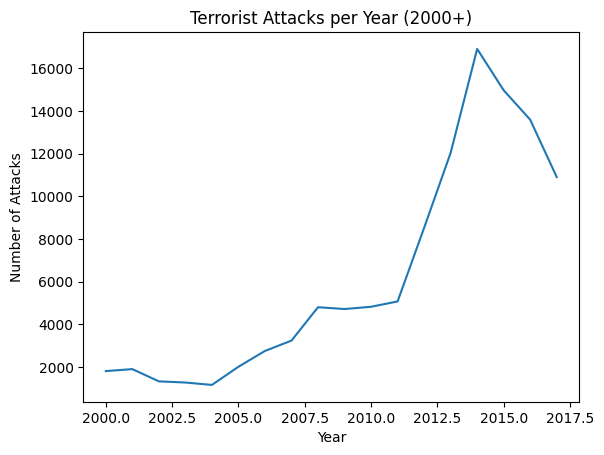

In [6]:
attacks_per_year = df['iyear'].value_counts().sort_index()

plt.figure()
attacks_per_year.plot()
plt.title('Terrorist Attacks per Year (2000+)')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.show()

### Top Countries by Number of Attacks

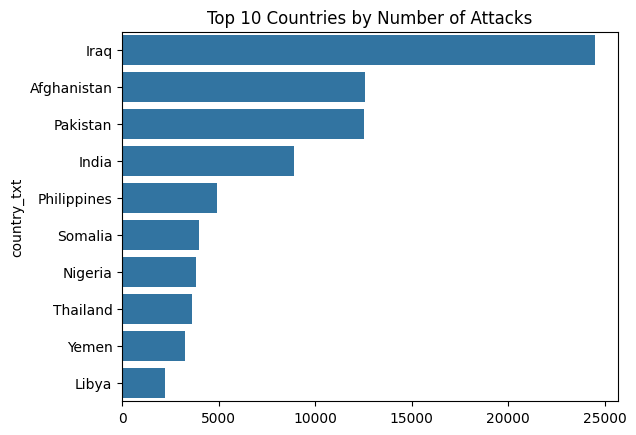

In [7]:
top_countries = df['country_txt'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Number of Attacks')
plt.show()

### Most Common Attack Types

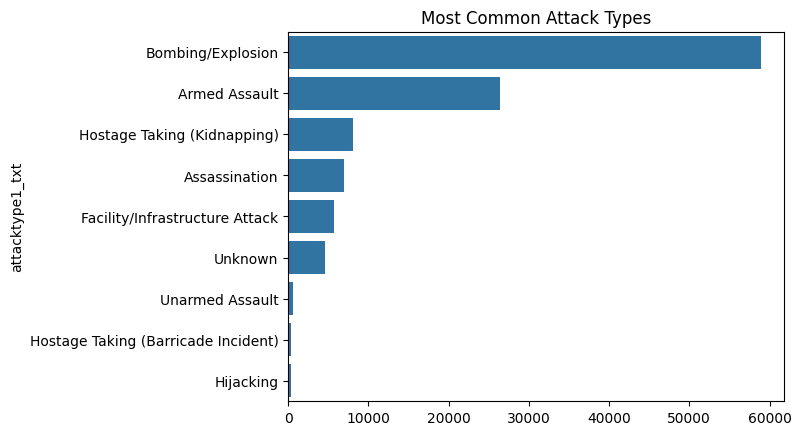

In [8]:
attack_types = df['attacktype1_txt'].value_counts().head(10)

plt.figure()
sns.barplot(x=attack_types.values, y=attack_types.index)
plt.title('Most Common Attack Types')
plt.show()

### Most Common Weapon Types

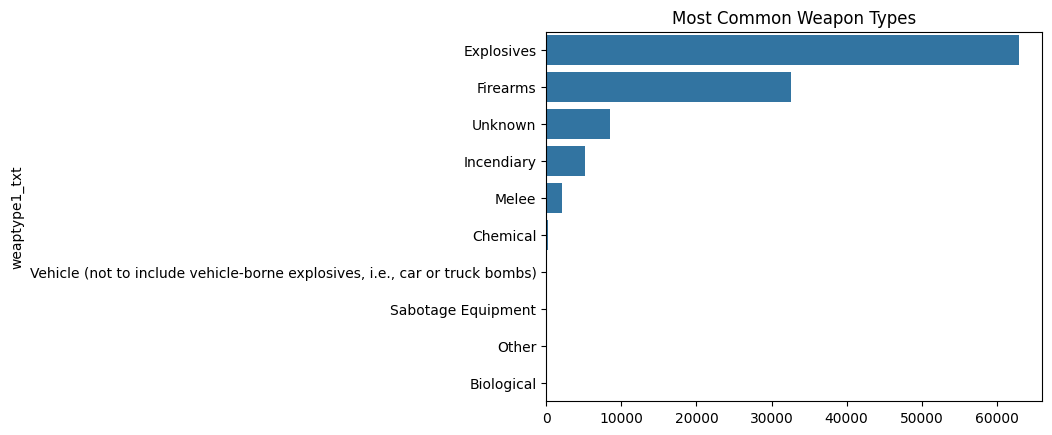

In [9]:
weapon_types = df['weaptype1_txt'].value_counts().head(10)

plt.figure()
sns.barplot(x=weapon_types.values, y=weapon_types.index)
plt.title('Most Common Weapon Types')
plt.show()

### Casualty Distribution

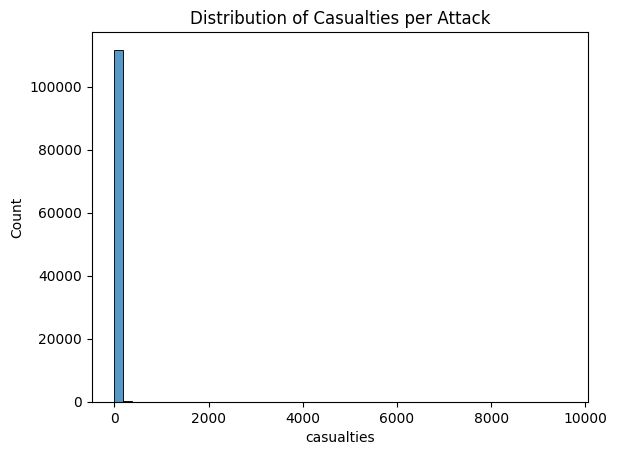

In [10]:
plt.figure()
sns.histplot(df['casualties'], bins=50)
plt.title('Distribution of Casualties per Attack')
plt.show()

### Casualties by Attack Type

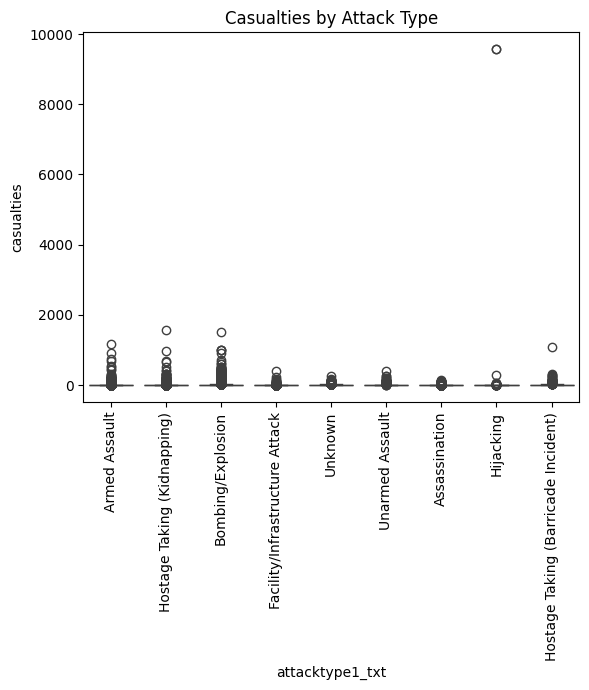

In [11]:
plt.figure()
sns.boxplot(x='attacktype1_txt', y='casualties', data=df)
plt.xticks(rotation=90)
plt.title('Casualties by Attack Type')
plt.show()

## 7. Data Transformation for Clustering

In [12]:
le = LabelEncoder()

df['attack'] = le.fit_transform(df['attacktype1_txt'])
df['target'] = le.fit_transform(df['targtype1_txt'])
df['weapon'] = le.fit_transform(df['weaptype1_txt'])

## 8. Standardize Features

In [13]:
features = df[['attack', 'target', 'weapon', 'log_casualties']]

scaler = StandardScaler()
X = scaler.fit_transform(features)

## 9. Determine Number of Clusters (Elbow Method)

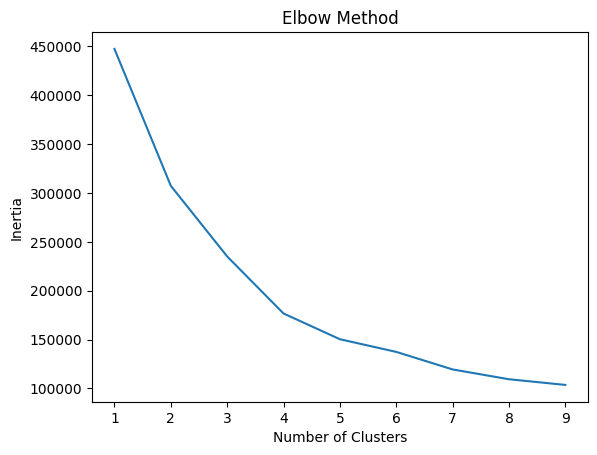

In [14]:
inertia = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(range(1, 10), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 10. Run K Means Clustering

In [15]:
kmeans = KMeans(n_clusters=3, random_state=0)
df['cluster'] = kmeans.fit_predict(X)

df.head()

,iyear,region_txt,country_txt,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound,casualties,log_casualties,attack,target,weapon,cluster
69835,2000,Sub-Saharan Africa,Namibia,Armed Assault,Business,Firearms,0.0,7.0,7.0,2.079442,0,2,4,2
69836,2000,Sub-Saharan Africa,Namibia,Hostage Taking (Kidnapping),Business,Firearms,0.0,7.0,7.0,2.079442,6,2,4,2
69837,2000,South Asia,India,Armed Assault,Police,Firearms,1.0,2.0,3.0,1.386294,0,12,4,1
69838,2000,Eastern Europe,Kosovo,Bombing/Explosion,Private Citizens & Property,Explosives,0.0,1.0,1.0,0.693147,2,13,2,1
69839,2000,Sub-Saharan Africa,Somalia,Armed Assault,Private Citizens & Property,Firearms,6.0,10.0,16.0,2.833213,0,13,4,1


## 11. Cluster Visualization

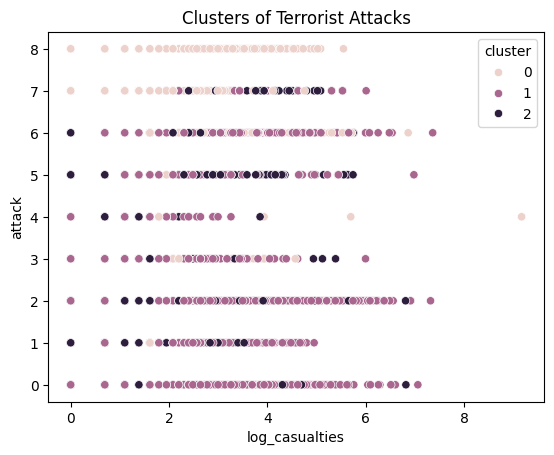

In [16]:
plt.figure()
sns.scatterplot(x=df['log_casualties'], y=df['attack'], hue=df['cluster'])
plt.title('Clusters of Terrorist Attacks')
plt.show()

### Cluster Sizes

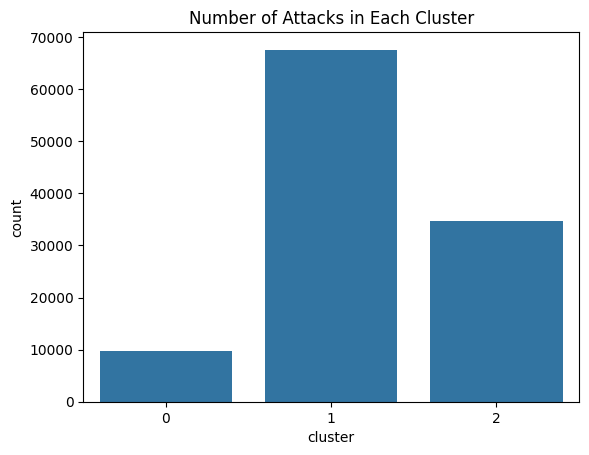

In [17]:
sns.countplot(x='cluster', data=df)
plt.title('Number of Attacks in Each Cluster')
plt.show()

## 12. Cluster Summary

In [18]:
df.groupby('cluster')[['casualties']].mean()

,casualties
cluster,
0,6.219171
1,7.319439
2,3.027871


## 13. Interpretation

The clustering results suggest three broad categories of terrorist attacks. The first cluster represents attacks with relatively low casualty counts and common attack methods such as bombings or small scale assaults. These incidents occur frequently and make up the majority of events in the dataset.

The second cluster contains attacks with moderate casualty counts and a variety of weapons and targets. These attacks appear more organized and may represent coordinated operations against government or infrastructure targets.

The third cluster represents rare but high impact attacks with extremely large casualty counts. Although these incidents occur far less frequently, they contribute disproportionately to the total number of casualties recorded in the dataset.

## 14. Future Work

Future analysis will explore additional clustering techniques and feature engineering approaches to better understand patterns in terrorist activity. Geographic patterns and temporal trends may also be incorporated in later stages of the project.